<a href="https://colab.research.google.com/github/manuellazarte/TP-Mineria-Datos-Pinguinos/blob/main/TP1_Lazarte_Larrubia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Práctico N°1 - Minería de Datos:

> **Año:** 2026  
> **Integrantes:**  
> * Larrubia, Agustín.  
> * Lazarte, Manuel.


## Introducción:
&emsp;El trabajo que se encuentra a continuación tiene como objetivo utilizar los conocimientos adquiridos en las Unidades 2 y 3 de la materia en el dataset 'penguins_size.csv' el cual contiene datos sobre distintas especies de pingüinos.

## Creación de ambiente e importación de dependencias:


In [ ]:
# Manejo de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import plotly.express as px
import seaborn as sns

# Flujo de datos
from sklearn.pipeline import Pipeline

# Preparación de datos
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE, Isomap
from sklearn.decomposition import PCA

import warnings
from scipy.sparse import SparseEfficiencyWarning
warnings.filterwarnings('ignore', message='.*connected components.*')
warnings.filterwarnings('ignore', category=SparseEfficiencyWarning)

# Algoritmos de Clustering
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score,silhouette_samples

from plotly.subplots import make_subplots
import plotly.graph_objects as go


## Funciones

In [ ]:
def grilla_tsne(param, valores, **fijos):
    fig = make_subplots(rows=1, cols=len(valores),
                        subplot_titles=[f'{param} = {v}' for v in valores])
    for i, v in enumerate(valores, start=1):
        tsne = TSNE(n_components=2, init='pca', random_state=42, **{param: v}, **fijos)
        emb = tsne.fit_transform(X_std)
        kl = tsne.kl_divergence_
        texto_kl = f'KL = {kl:.3f}' if kl < 1e6 else 'KL no calculada'
        fig.layout.annotations[i - 1].text += f'<br>{texto_kl}'
        for esp, color in colores.items():
            m = np.asarray(y_especie == esp)
            fig.add_trace(go.Scatter(x=emb[m, 0], y=emb[m, 1], mode='markers',
                                     name=esp, marker=dict(color=color, size=4),
                                     showlegend=(i == 1)), row=1, col=i)
    fig.update_layout(height=400, title=f't-SNE 2D variando {param}')
    fig.show()

## Adquisición y preparación de los datos:

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

### Lectura :

In [ ]:
file_path = 'penguins_size.csv' #Agus
#file_path = '/content/drive/MyDrive/FCEIA/Minería de datos/TPs/TP1/penguins_size.csv' #Manu

df = pd.read_csv(file_path, sep=';')

### Analisis de la estructura de los datos:

&emsp;Realizamos el debido analisis de la estructura y contenido del dataset para ver detalles sobre su información general: cantidad de filas (muestras), nombre y tipo de dato de los atributos, cantidad de valores no nulos.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 347 entries, 0 to 346
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Especie                  347 non-null    object 
 1   Longitud Culmen (mm)     345 non-null    float64
 2   Profundidad Culmen (mm)  345 non-null    float64
 3   Longitud Aleta (mm)      345 non-null    float64
 4   Masa corporal (g)        345 non-null    float64
 5   Sexo                     337 non-null    object 
 6   Unnamed: 6               0 non-null      float64
 7   Unnamed: 7               0 non-null      float64
dtypes: float64(6), object(2)
memory usage: 21.8+ KB


In [ ]:
display(df.head())

,Especie,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g),Sexo,Unnamed: 6,Unnamed: 7
0,Adelie Penguin,39.1,18.7,181.0,3750.0,MALE,NaN,NaN
1,Adelie Penguin,39.5,17.4,186.0,3800.0,FEMALE,NaN,NaN
2,Adelie Penguin,40.3,18.0,195.0,3250.0,FEMALE,NaN,NaN
3,Adelie Penguin,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Adelie Penguin,36.7,19.3,193.0,3450.0,FEMALE,NaN,NaN


In [ ]:
df.value_counts("Sexo", dropna=False)

,count
Sexo,
MALE,170
FEMALE,166
NaN,10
.,1


### Limpieza de datos:

&emsp;Como se pudo observar en el paso anterior hay dos atributos \(columnas) que no cuentan con nombre y tampoco poseen contenido alguno \(0 non-null) por lo que procedemos a su eliminación, como tambien para todo registro \(fila) que no posea medidas aunque si tenga especificada la especie.

In [ ]:
df = df.dropna(axis=1, how='all')
df = df.dropna(subset=df.columns.drop('Especie'), how='all')

print('Duplicados exactos:', df.duplicated().sum())
display(df[df.duplicated(keep=False)])

df['Sexo'] = df['Sexo'].replace('.', np.nan)

df = df.drop_duplicates()

Duplicados exactos: 3


,Especie,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g),Sexo
63,Adelie Penguin,41.1,18.2,192.0,4050.0,MALE
126,Adelie Penguin,38.8,17.6,191.0,3275.0,FEMALE
127,Adelie Penguin,38.8,17.6,191.0,3275.0,FEMALE
206,Adelie Penguin,41.1,18.2,192.0,4050.0,MALE
254,Gentoo penguin,59.6,17.0,230.0,6050.0,MALE
256,Gentoo penguin,59.6,17.0,230.0,6050.0,MALE


Se detectaron 3 registros duplicados exactos. Dado que no podemos confirmar que es el mismo animal y que la coincidencia exacta es improbable por azar y probablemente corresponde a un error de carga. Se eliminó la segunda aparición de cada par para no ponderar doble esas observaciones

**Limpieza aplicada**

- Se eliminan las columnas totalmente vacías (`Unnamed`) y las filas sin ninguna medición.
- El valor `'.'` en `Sexo` se trata como faltante.
- Se eliminan los registros duplicados exactos.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 342 entries, 0 to 346
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Especie                  342 non-null    object 
 1   Longitud Culmen (mm)     342 non-null    float64
 2   Profundidad Culmen (mm)  342 non-null    float64
 3   Longitud Aleta (mm)      342 non-null    float64
 4   Masa corporal (g)        342 non-null    float64
 5   Sexo                     333 non-null    object 
dtypes: float64(4), object(2)
memory usage: 18.7+ KB


### Análisis exploratorio:

#### Observación de outliers

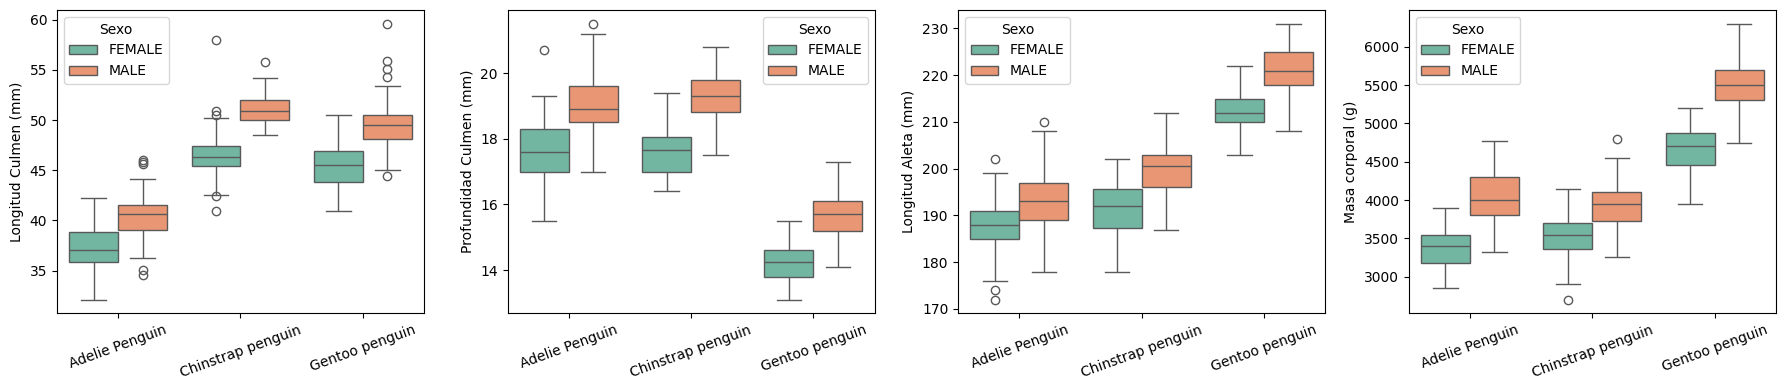

In [ ]:
cols = ['Longitud Culmen (mm)', 'Profundidad Culmen (mm)', 'Longitud Aleta (mm)', 'Masa corporal (g)']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, c in zip(axes, df[cols]):
    sns.boxplot(data=df, x='Especie', y=c, hue='Sexo',
                hue_order=['FEMALE', 'MALE'], palette='Set2', ax=ax)
    ax.set_xlabel(''); ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

In [ ]:
def outliers_extremos(df, variables, k=3.0, grupo=('Especie', 'Sexo')):
    """Filas fuera de [Q1 - k*IQR, Q3 + k*IQR] dentro de cada (especie, sexo)."""
    d = df[df['Sexo'].isin(['FEMALE', 'MALE'])]
    filas = []
    for clave, g in d.groupby(list(grupo)):
        for v in variables:
            q1, q3 = g[v].quantile(.25), g[v].quantile(.75)
            iqr = q3 - q1
            lo, hi = q1 - k * iqr, q3 + k * iqr
            for idx, val in g.loc[(g[v] < lo) | (g[v] > hi), v].items():
                filas.append({'fila': idx, 'Especie': clave[0], 'Sexo': clave[1], 'variable': v,
                              'valor': val, 'límite_inf': round(lo, 1), 'límite_sup': round(hi, 1)})
    return pd.DataFrame(filas)

Decisión sobre outliers. Se eliminaron 2 observaciones extremas (fuera de 3*IQR) calculados dentro de cada especie y sexo.

se retiran por robustez, porque son atípicas respecto de su grupo y estiran los ejes de las proyecciones (por ejemplo, en Isomap). Aunque el efecto sobre el análisis es mínimo: la varianza explicada por las dos primeras componentes de PCA pasa de 0.882 a 0.883.

In [ ]:
extremos = outliers_extremos(df, cols)
display(extremos)

df = df.drop(index=extremos['fila'].unique())
print(df.shape)

,fila,Especie,Sexo,variable,valor,límite_inf,límite_sup
0,170,Chinstrap penguin,FEMALE,Longitud Culmen (mm),58.0,39.6,53.2
1,254,Gentoo penguin,MALE,Longitud Culmen (mm),59.6,40.9,57.7


(340, 6)


In [ ]:
#excluimos Especie y Sexo
X = df.drop(['Especie', 'Sexo'], axis=1)

#almacenamos para colorear el grafico mas adelante
y_especie = df['Especie']
y_sexo = df['Sexo']

display(X.head())

,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g)
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
4,36.7,19.3,193.0,3450.0
5,39.3,20.6,190.0,3650.0


####Observamos la correlación entre atributos:

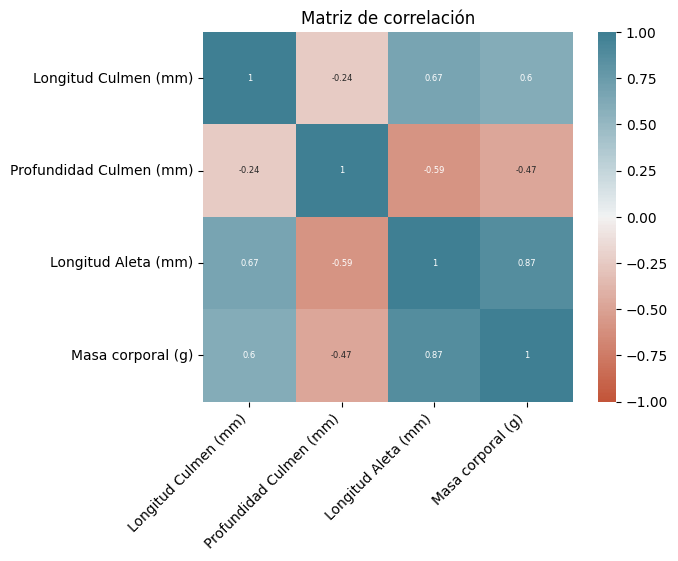

In [ ]:
corr = X.corr()
ax = sns.heatmap(corr,vmin=-1, vmax=1, center=0, cmap=sns.diverging_palette(20, 220, n=200), square=True, annot = True, annot_kws = {'size': 6})
ax.set_xticklabels(ax.get_xticklabels(), rotation=45,horizontalalignment='right')
plt.title('Matriz de correlación')
plt.show()

&emsp;Se observa una correlación positiva fuerte entre `Longitud Aleta (mm)` y `Masa corporal (g)`, moderada entre `Longitud Culmen (mm)` - `Masa corporal (g)` y `Longitud culmen (mm)` - `Longitud Aleta (mm)`
Al mismo tiempo también se puede ver una correlación negativa moderada entre `Profundidad Culmen (mm)` - `Masa corporal (g)` y `Profundida Culmen (mm)` - `Longitud Aleta (mm)`

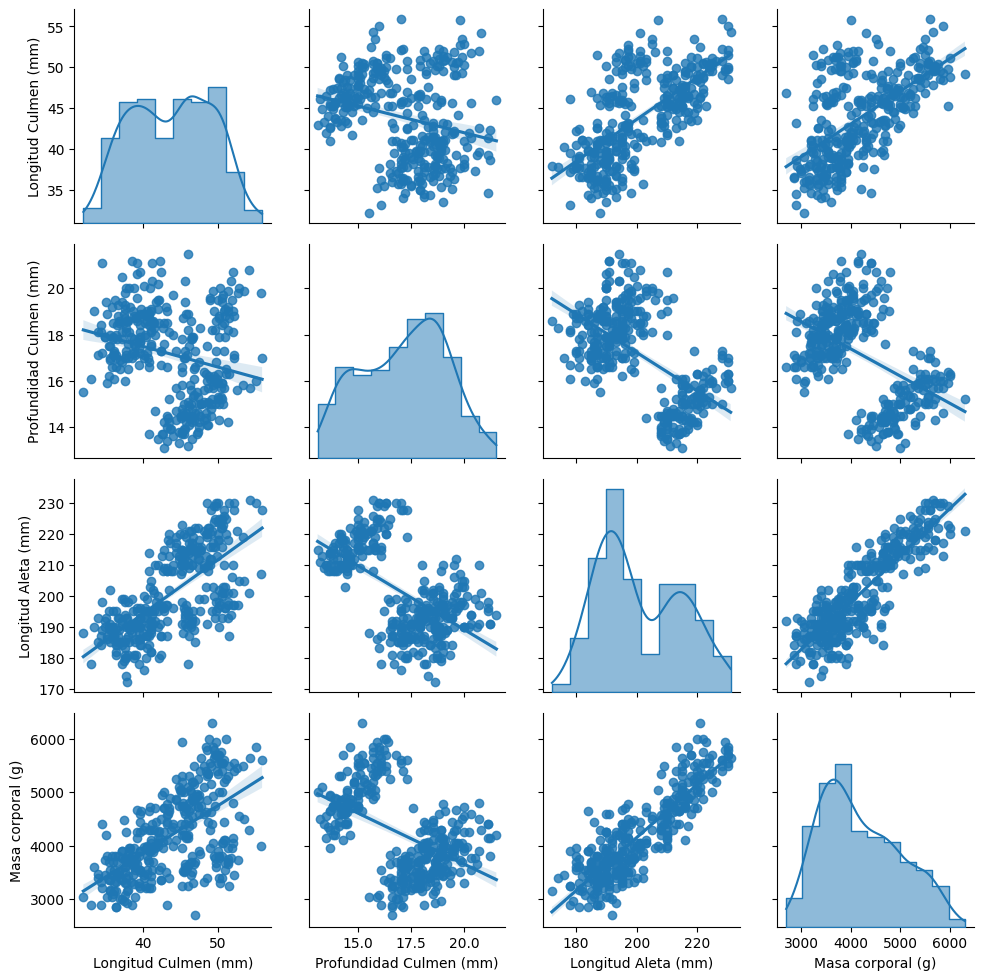

In [ ]:
g = sns.PairGrid(X)
g.map_diag(sns.histplot, kde=True, element='step')
g.map_offdiag(sns.regplot)

&emsp;En los scatterplots, Longitud Aleta (mm) y Masa corporal (g) tienen la relación positiva más fuerte, casi lineal. Longitud Culmen (mm) también crece junto con ambas, pero con más dispersión. Profundidad Culmen (mm) muestra una relación negativa con las demás, aunque con Longitud Culmen (mm) es muy débil.

&emsp;Esa relación negativa de Profundidad Culmen (mm) con Longitud Aleta (mm) y Masa corporal (g) es engañosa ya se ven dos grupos separados y dentro de cada uno la relación es positiva. La pendiente negativa aparece solo por la diferencia entre los grupos. En el gráfico de Longitud Culmen (mm) contra Profundidad Culmen (mm) incluso se distinguen tres grupos.

&emsp;En la diagonal, Longitud Aleta (mm) y Longitud Culmen (mm) son claramente bimodales. Profundidad Culmen (mm) tiene un pico cerca de 18 mm y otro menos marcado cerca de 15 mm. Masa corporal (g) es unimodal con la mayoría de los valores entre 3500 y 4000 g, con una cola hacia valores más altos.

### Normalización:

&emsp;Como se observa en la estructura de arriba tenemos variables que poseen distintas escalas como por ejemplo Longitud Culmen, Profundidad Culmen y Longitud aleta en milimetros contra Masa corporal que esta en gramos y ademas de escalas poseen distinto ordenes de magnitud, por lo que es necesario normalizar estas variables para hacer que todas contribuyan de forma equitativa al análisis, evitando que la Masa Corporal domine los resultados simplemente por tener valores numericos más grandes

In [ ]:
scaler = StandardScaler().set_output(transform="pandas")
X_std = scaler.fit_transform(X)
X_std.describe()

,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g)
count,3.400000e+02,3.400000e+02,3.400000e+02,3.400000e+02
mean,1.044916e-15,-1.128509e-15,8.359326e-16,3.343731e-16
std,1.001474e+00,1.001474e+00,1.001474e+00,1.001474e+00
min,-2.194932e+00,-2.048032e+00,-2.070545e+00,-1.880756e+00
25%,-8.668709e-01,-7.963660e-01,-7.804072e-01,-8.134245e-01
50%,7.773615e-02,7.600729e-02,-2.786867e-01,-1.855827e-01
75%,8.586736e-01,7.840204e-01,8.681029e-01,6.933959e-01
max,2.256879e+00,2.200047e+00,2.158241e+00,2.639706e+00


## Reducción de Dimensionalidad:

### PCA:

#### 1. Varianza acumulada

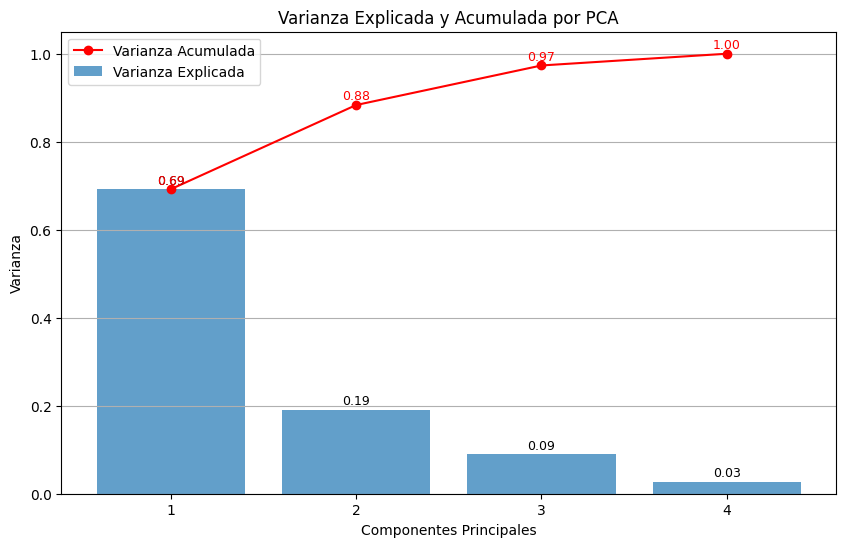

In [ ]:
# Aplicamos PCA sobre las variables ya estandarizadas
pca = PCA().set_output(transform="pandas")
df_pca = pca.fit_transform(X_std)

pca.explained_variance_ratio_

df_pca['Especie'] = y_especie

# Varianza explicada y acumulada
var_exp = pca.explained_variance_ratio_
var_cum = np.cumsum(var_exp)
n_comp = len(var_exp)

# Crear figura
fig, ax = plt.subplots(figsize=(10,6))

# Barras: varianza explicada
bars = ax.bar(range(1, n_comp+1), var_exp, alpha=0.7, label='Varianza Explicada')

# Línea: varianza acumulada
line = ax.plot(range(1, n_comp+1), var_cum, color='red', marker='o', label='Varianza Acumulada')

# Etiquetas sobre las barras
for bar, v in zip(bars, var_exp):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.005, f"{v:.2f}", ha='center', va='bottom', fontsize=9)

# Etiquetas sobre los puntos de la línea
for i, v in enumerate(var_cum, start=1):
    ax.text(i, v + 0.005, f"{v:.2f}", color='red', ha='center', va='bottom', fontsize=9)

# Etiquetas y estilo
ax.set_xlabel('Componentes Principales')
ax.set_ylabel('Varianza')
ax.set_title('Varianza Explicada y Acumulada por PCA')
ax.set_xticks(range(1, n_comp+1))
ax.legend()
ax.grid(axis='y')

plt.show()

&emsp;Como podemos observar el criterio 75% a 85% de variancia acumulada con dos componentes ya se cumple por encima de 3 puntos porcentuales.

&emsp;La mayor parte de la varianza explicada se acumula en los primeros dos componentes, obteniendo un 69% y 19% respectivamente de la varianza.

####2. Kaisser

&emsp;El criterio de Kaisser indica que se deben aceptar los eigenvalues con un valor >= 10% (0.1).

&emsp;Bajo este criterio, solo las dos primeros cumplen con ese criterio.

In [ ]:
var_exp

array([0.69195648, 0.19140184, 0.08995669, 0.02668499])

####3. Gráfico del codo:

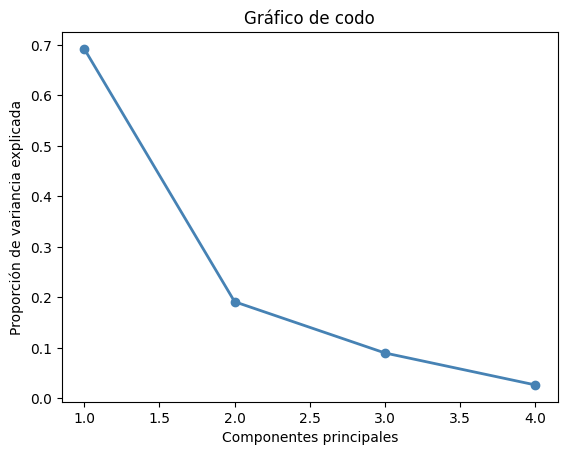

In [ ]:
PC_values = np.arange(pca.n_components_) + 1
plt.plot(PC_values, pca.explained_variance_ratio_, 'o-', linewidth=2, color='steelblue')
plt.title('Gráfico de codo')
plt.xlabel('Componentes principales')
plt.ylabel('Proporción de variancia explicada')
plt.show()

&emsp;En el gráfico de codo se observa una caída abrupta en la proporción de varianza explicada luego del segundo componente. A partir del tercer componente, la curva comienza a aplanarse, lo que sugiere que el 'codo' se encuentra en el componente 2. Esto coincide con los criterios de Kaiser y Varianza Acumulada, confirmando que 2 componentes principales son los óptimos para este dataset.

#### Criterio elegido:

&emsp;Elegimos el criterio de varianza acumulada por ser el más interpretable (retiene 88% de la información) y porque permite la visualización en 2D.

####Gráfico PCA:

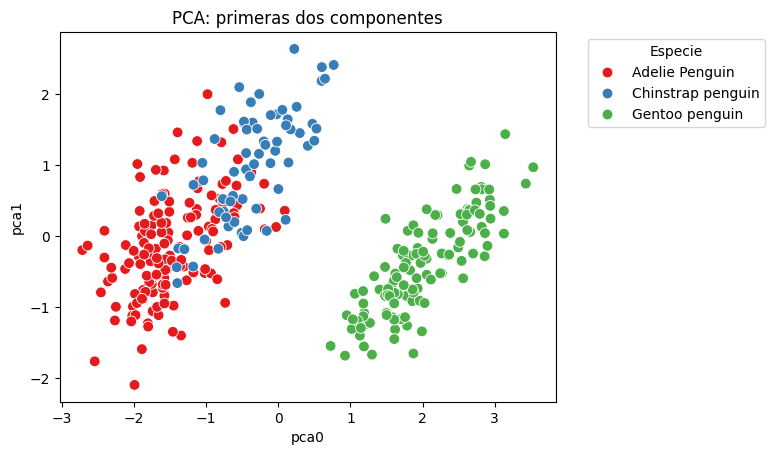

In [ ]:
# Visualizamos en scatterplot las primeras dos componentes
sns.scatterplot(
    x=df_pca['pca0'],
    y=df_pca['pca1'],
    hue=df_pca['Especie'],
    palette='Set1',
    s=60
)

plt.xlabel('pca0')
plt.ylabel('pca1')
plt.title('PCA: primeras dos componentes')
plt.legend(title='Especie', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

#### Observación:

&emsp;En el gráfico obtenido se observa claramente un grupo bien definido correspondiente a la especie Gentoo. Por otro lado, las especies Adelie y Chinstrap se encuentran agrupadas en el lado izquierdo del gráfico, presentando un solapamiento considerable entre sí.

###Isomap:

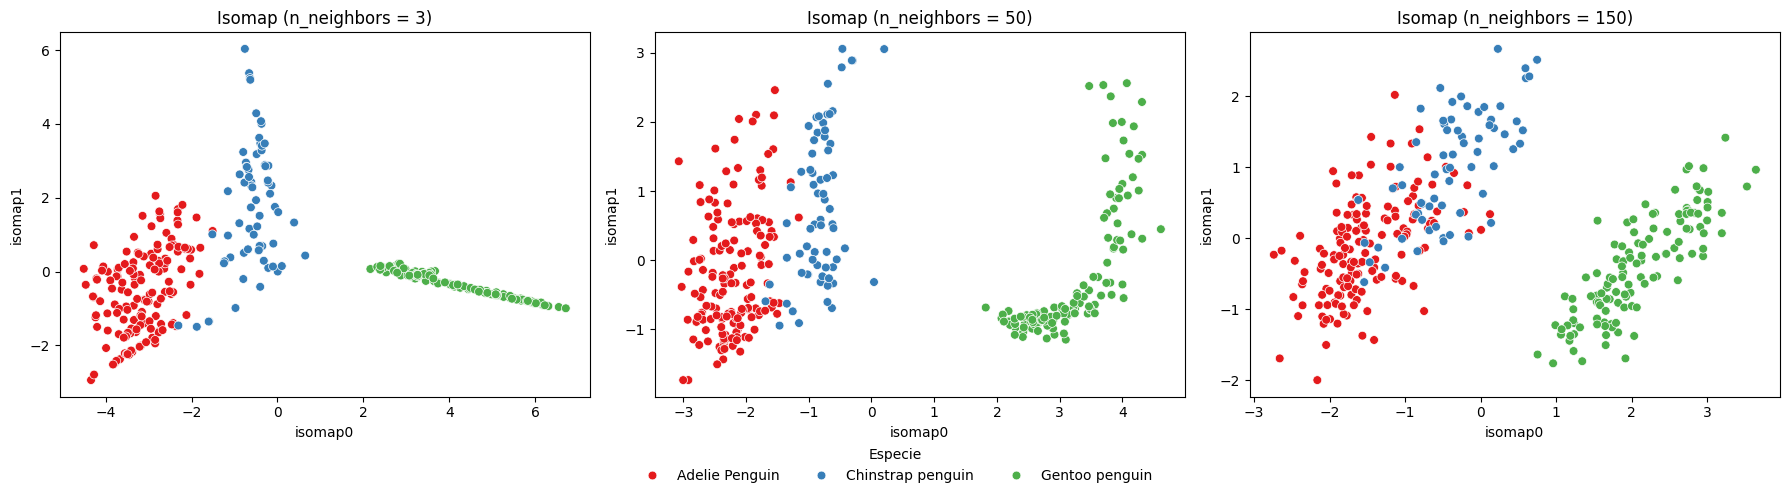

In [ ]:
ks = [3, 50, 150]
colores = {'Adelie Penguin': '#E41A1C', 'Chinstrap penguin': '#377EB8', 'Gentoo penguin': '#4DAF4A'}

fig, axes = plt.subplots(1, len(ks), figsize=(6 * len(ks), 5))
for ax, k in zip(axes, ks):
    emb = Isomap(n_neighbors=k, n_components=2).fit_transform(X_std)
    sns.scatterplot(x=emb[:, 0], y=emb[:, 1], hue=y_especie.values, hue_order=list(colores),
                    palette=colores, s=40, ax=ax)
    ax.set_title(f'Isomap (n_neighbors = {k})'); ax.set_xlabel('isomap0'); ax.set_ylabel('isomap1')

handles, labels = axes[-1].get_legend_handles_labels()
for ax in axes:
    ax.get_legend().remove()
fig.legend(handles, labels, title='Especie', loc='lower center', ncol=3, frameon=False,
           bbox_to_anchor=(0.5, 0))
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

#### Observación:

En la representación se observa lo siguiente:

&emsp;Gentoo pasa de una línea casi recta sin ancho que se desplaza de manera horizontal sobre la figura (k=3 y 6) a una forma de "L" con ancho (k=50), con un tramo horizontal denso y otro vertical más disperso

&emsp;Chinstrap forma un brazo vertical muy estirado con k=3 (llega a y≈6), menos con k=6 y se acorta bastante con k=50 (y≈3), donde queda como una banda vertical al lado de Adelie

&emsp;Adelie pasa de una nube dispersa a la izquierda (k=3) a una nube alargada en diagonal (k=6) y a una banda alta (k=50).

&emsp;Adelie y Chinstrap se distinguen en los tres casos, con una pequeña zona de contacto cerca de x≈-2 a -1. Gentoo queda separada del resto en todos.

&emsp;Con k=150 los vecinos cruzan entre especies, se forman "atajos" y las distancias geodésicas se parecen a las euclídeas, por lo que se pierde la separación local y el gráfico se asemeja al de PCA.

**Valor más apropiado**. Consideramos k=50 el más apropiado: es aproximadamente el menor k que conecta el grafo, y aun así mantiene separadas a Adelie y Chinstrap, a diferencia de k=150.

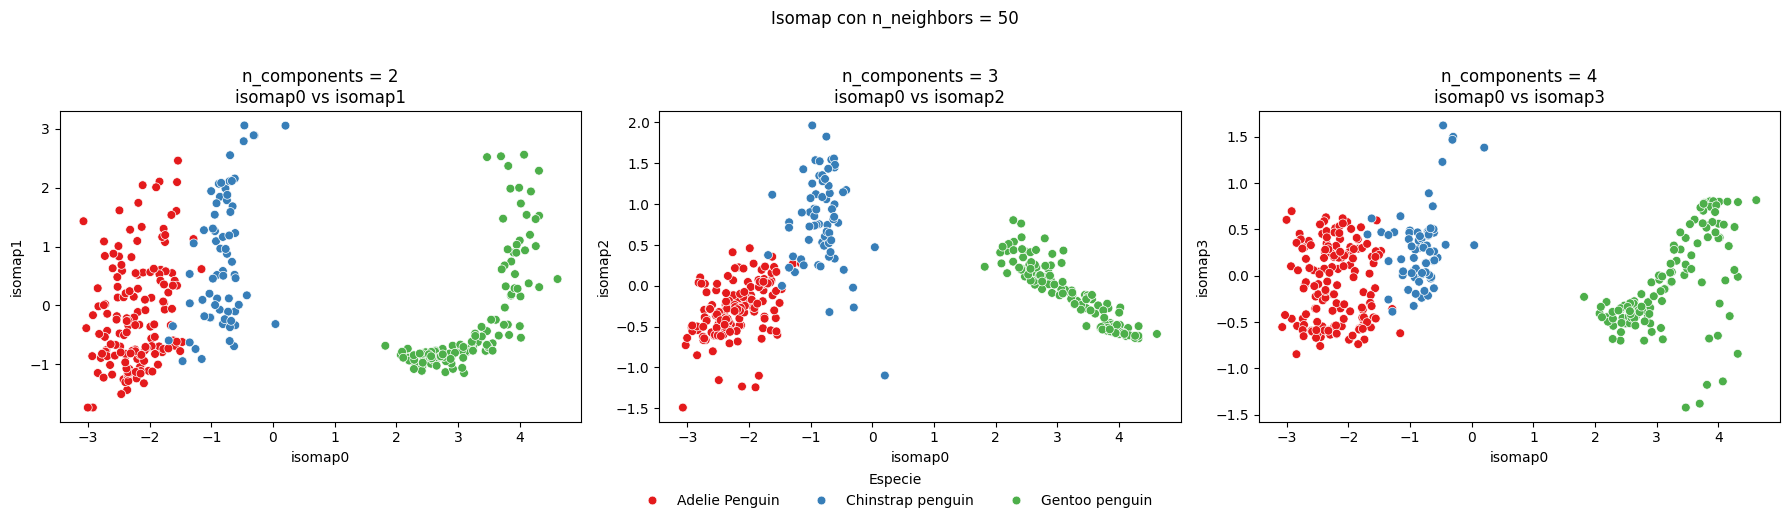

In [ ]:
N_VECINOS = 50
componentes = [2, 3, 4]
colores = {'Adelie Penguin': '#E41A1C', 'Chinstrap penguin': '#377EB8', 'Gentoo penguin': '#4DAF4A'}

fig, axes = plt.subplots(1, len(componentes), figsize=(6 * len(componentes), 5))
embs = {}
for ax, c in zip(axes, componentes):
    emb = Isomap(n_neighbors=N_VECINOS, n_components=c).fit_transform(X_std)
    embs[c] = emb
    sns.scatterplot(x=emb[:, 0], y=emb[:, c - 1], hue=y_especie.values, hue_order=list(colores),
                    palette=colores, s=40, ax=ax)
    ax.set_title(f'n_components = {c}\nisomap0 vs isomap{c - 1}')
    ax.set_xlabel('isomap0'); ax.set_ylabel(f'isomap{c - 1}')

handles, labels = axes[-1].get_legend_handles_labels()
for ax in axes:
    ax.get_legend().remove()
fig.suptitle(f'Isomap con n_neighbors = {N_VECINOS}', y=1.02)
fig.legend(handles, labels, title='Especie', loc='lower center', ncol=3, frameon=False,
           bbox_to_anchor=(0.5, 0))
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

Los primeros ejes del embedding no cambian al aumentar n_components, por lo que el gráfico 2D es el mismo. En el panel de isomap0 vs isomap1, Gentoo se separa claramente de las otras dos especies mientra que Adelie y Chinstrap se distinguen con una zona de contacto.

Al graficar isomap0 contra isomap2, las tres especies siguen reconociéndose pero Adelie y Chinstrap se mezclan más

Con isomap3 la estructura se vuelve difusa y los grupos casi no se separan.

Es decir, el primer eje concentra la separación entre especies y los ejes adicionales aportan poco a lo que se puede visualizar, por lo que se trabaja con 2 componentes.

###t-SNE:

In [ ]:
# Colores automáticos según categorías
categories = y_especie.unique()
colors = sns.color_palette('Set1', n_colors=len(categories))
colors = colors.as_hex()

#### Grillas:

In [ ]:
grilla_tsne('perplexity', [2, 5, 30, 50, 100])

In [ ]:
grilla_tsne('max_iter', [300, 500, 1000, 2000])

In [ ]:
for n in [1, 2, 3]:
    tsne = TSNE(n_components=n, init='pca', random_state=42).fit(X_std)
    print(f'{n} componente(s): KL = {tsne.kl_divergence_:.3f}')

1 componente(s): KL = 0.547
2 componente(s): KL = 0.387
3 componente(s): KL = 0.267


#### Observación:

Aplicamos t-SNE sobre los datos estandarizados variando las iteraciones, la perplejidad y la cantidad de componentes.

Con 300 iteraciones ya se distinguen las tres especies, pero los grupos están más juntos y la KL es más alta (0,459). Desde 500 en adelante el gráfico casi no cambia y la KL se mantiene en torno a 0,39, así que usamos 1000.

Al aumentar las componentes la KL baja (0,547 con 1, 0,387 con 2 y 0,267 con 3), es decir que con más dimensiones se conservan mejor los vecinos originales.

La perplejidad fue lo que más cambió los resultados. No la comparamos con la KL porque al cambiar la perplejidad los valores no son comparables. Con 2 y 5 los puntos quedan en muchos grupos chicos, y con 100 Adelie y Chinstrap empiezan a mezclarse. Elegimos 30, donde se ven tres grupos claros: Gentoo bien separado y Adelie y Chinstrap cerca, con algunos puntos superpuestos.

## Agrupamiento:

###K-means

&emsp;A partir de lo observado en PCA e Isomap, esperamos que K-means encuentre tres grupos asociados a las especies: Gentoo claramente separada del resto y un posible solapamiento entre Adelie y Chinstrap. El agrupamiento se realiza sobre las cuatro variables estandarizadas y con el conjunto de datos completo, ya que el objetivo es describir su estructura y no predecir sobre datos nuevos.

#### Gráfico de codo:

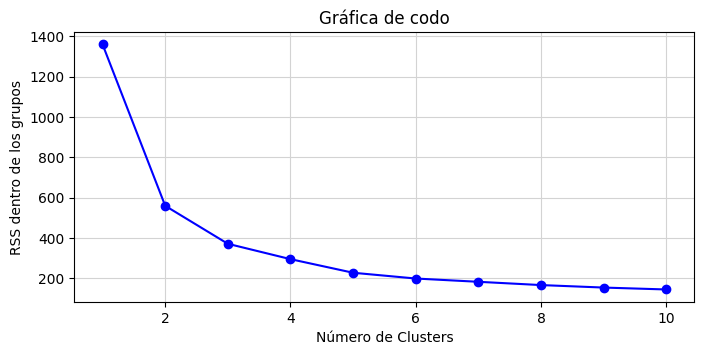

In [ ]:
Nc = range(1, 11)
kmeans = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_std) for k in Nc]
inertias = [model.inertia_ for model in kmeans]

plt.figure(figsize=(8, 3.5))
plt.plot(Nc, inertias, "bo-")
plt.xlabel('Número de Clusters')
plt.ylabel('RSS dentro de los grupos')
plt.title('Gráfica de codo')
plt.grid(color='lightgray')
plt.show()

#### Gap Statistic:

Número óptimo de clusters según GAP: 9


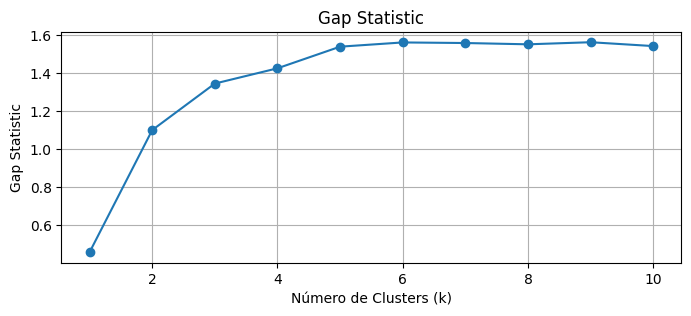

In [ ]:
np.random.seed(42)
gaps = []
for k, model in zip(Nc, kmeans):
    # Referencias uniformes sobre el rango de cada variable (10 repeticiones)
    ref = [KMeans(n_clusters=k, random_state=42, n_init=10)
           .fit(np.random.uniform(X_std.min(), X_std.max(), X_std.shape)).inertia_
           for _ in range(10)]
    gaps.append(np.mean(np.log(ref)) - np.log(model.inertia_))

print("Número óptimo de clusters según GAP:", np.argmax(gaps) + 1)

plt.figure(figsize=(8, 3))
plt.plot(Nc, gaps, marker='o')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Gap Statistic')
plt.title('Gap Statistic')
plt.grid()
plt.show()

#### Coeficiente de Silhouette:

Número óptimo de clusters según Silhouette: 2


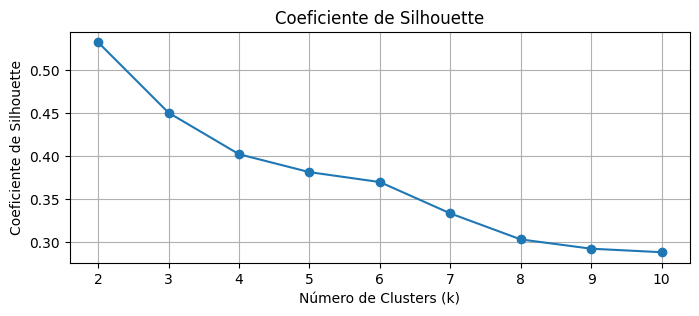

In [ ]:
silhouette_scores = [silhouette_score(X_std, model.labels_) for model in kmeans[1:]]
print("Número óptimo de clusters según Silhouette:", np.argmax(silhouette_scores) + 2)

plt.figure(figsize=(8, 3))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Coeficiente de Silhouette')
plt.title('Coeficiente de Silhouette')
plt.grid()
plt.show()

#### Observación:

&emsp;Se puede observar que los criterios no coinciden.
  
En el gráfico de codo la mayor caída de la inercia se da entre k=1 y k=2, y a partir de k=3–4 la curva se aplana.

El coeficiente de Silhouette es máximo en k=2 (0,53) y decrece de forma monótona.

&emsp;El GAP crece hasta k=5 y luego se estabiliza en una meseta, con su máximo en k=6 (valor prácticamente igual al de k=9), por lo que a partir de k=5 agregar clusters no mejora la estructura encontrada.

&emsp;La discrepancia refleja una estructura jerárquica: el nivel más marcado separa a Gentoo del resto (lo que favorece a Silhouette), mientras que el GAP detecta subgrupos adicionales dentro de las especies.

In [ ]:
k_opt = 3

kmeans_final = KMeans(n_clusters=k_opt, random_state=42, n_init=10).fit(X_std)

df_km = X.copy()
df_km['Cluster'] = kmeans_final.labels_.astype(str)

&emsp;Elegimos k=3 para el modelo final. Si bien no es el óptimo según Silhouette (k=2) ni según GAP (k≈6), es un valor admitido por el gráfico de codo y el único en el que cada cluster se corresponde con una especie. Con k=2 se agrupan dos especies distintas y con k≥4 se subdividen especies ya aisladas. Esta elección incorpora conocimiento externo sobre el problema (la existencia de tres especies) además de los criterios internos.

In [ ]:
column_names = ['Longitud Culmen (mm)', 'Profundidad Culmen (mm)', 'Longitud Aleta (mm)']

fig = px.scatter_3d(df_km, x=column_names[0], y=column_names[1], z=column_names[2],
                    color='Cluster', title=f'K-means (k = {k_opt})', color_discrete_map=colores)
fig.show()

fig = px.scatter_3d(df_km, x=column_names[0], y=column_names[1], z=column_names[2],
                    color=y_especie, title='Especies reales', color_discrete_map=colores)
fig.show()

&emsp;Para el gráfico se utilizan Longitud Culmen, Profundidad Culmen y Longitud Aleta; se descarta Masa corporal por su fuerte correlación con Longitud Aleta. Gentoo forma un grupo aislado (aletas largas y culmen poco profundo) que K-means recupera sin errores. Adelie y Chinstrap comparten rangos de profundidad de culmen y de aleta y se diferencian principalmente por la longitud del culmen; en la zona de contacto entre ambas se concentran los errores de asignación. Esto confirma la hipótesis inicial: tres grupos, con Gentoo bien separada y solapamiento parcial entre Adelie y Chinstrap.

###Clustering jerárquico

In [ ]:
def calculate_intra_cluster_dispersion(X, k, linkage='ward'):
    clustering = AgglomerativeClustering(n_clusters=k, linkage=linkage)
    labels = clustering.fit_predict(X)

    # Convert X to a NumPy array for integer-based indexing
    X_np = X.to_numpy() if isinstance(X, pd.DataFrame) else X

    # Calcula los centroides de los clústeres como la media de los puntos dentro de cada clúster
    centroids = np.array([np.mean(X_np[labels == i], axis=0) for i in range(k)])

    # Calcula la dispersión intraclúster sumando las distancias al cuadrado entre los puntos y sus centroides
    # np.linalg.norm calcula la norma (distancia euclidiana) entre los puntos y el centroide correspondiente
    intra_cluster_dispersion = np.sum(np.linalg.norm(X_np[labels] - centroids[labels], axis=1)**2)
    return intra_cluster_dispersion

gaps = []
max_k = 10
for k in range(1, max_k + 1):
    # Calcula la dispersión intraclúster en los datos reales para 'k' clústeres
    X_std_numerical = X_std.select_dtypes(include=np.number)
    real_inertia = calculate_intra_cluster_dispersion(X_std_numerical, k, linkage='ward')

    inertia_list = []
    for _ in range(10):
      random_data = np.random.rand(*X_std_numerical.shape)
      intra_cluster_dispersion = calculate_intra_cluster_dispersion(random_data, k)
      inertia_list.append(intra_cluster_dispersion)

    reference_inertia = np.mean(inertia_list)

    gap = np.log(reference_inertia) - np.log(real_inertia)
    gaps.append(gap)

optimal_k = np.argmax(gaps) + 1

Número seleccionado de clusters según el Gap Statistic: 3


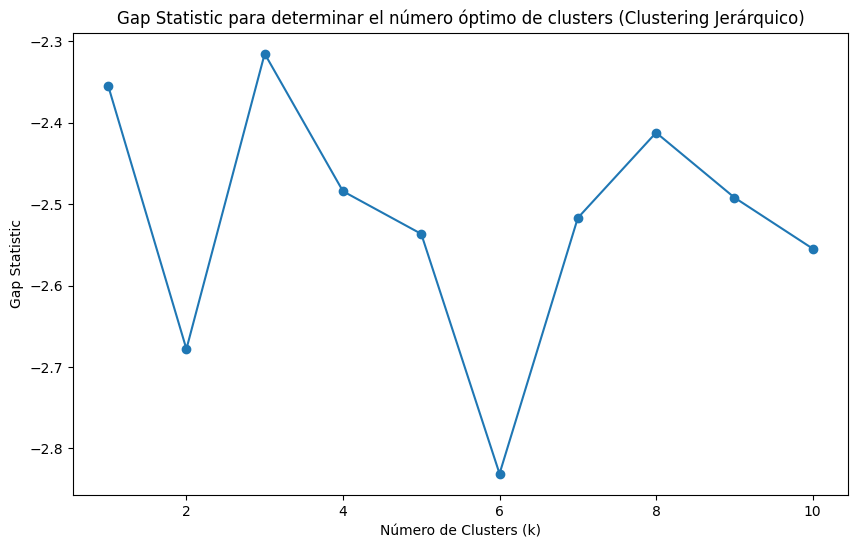

In [ ]:
print("Número seleccionado de clusters según el Gap Statistic:", optimal_k)

plt.figure(figsize=(10, 6))
plt.plot(range(1, max_k + 1), gaps, marker='o')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Gap Statistic')
plt.title('Gap Statistic para determinar el número óptimo de clusters (Clustering Jerárquico)')
plt.show()

#### Coeficiente de Silhouette

In [ ]:
def calculate_silhouette(X_scaled, k, linkage='ward'):
    clustering = AgglomerativeClustering(n_clusters=k, linkage=linkage)
    labels = clustering.fit_predict(X_scaled)
    silhouette_avg = silhouette_score(X_scaled, labels)
    sample_silhouette_values = silhouette_samples(X_scaled, labels)
    return silhouette_avg, sample_silhouette_values

max_k = 15

silhouette_scores = []
for k in range(2, max_k + 1):
    silhouette_avg, _ = calculate_silhouette(X_std, k)
    silhouette_scores.append(silhouette_avg)

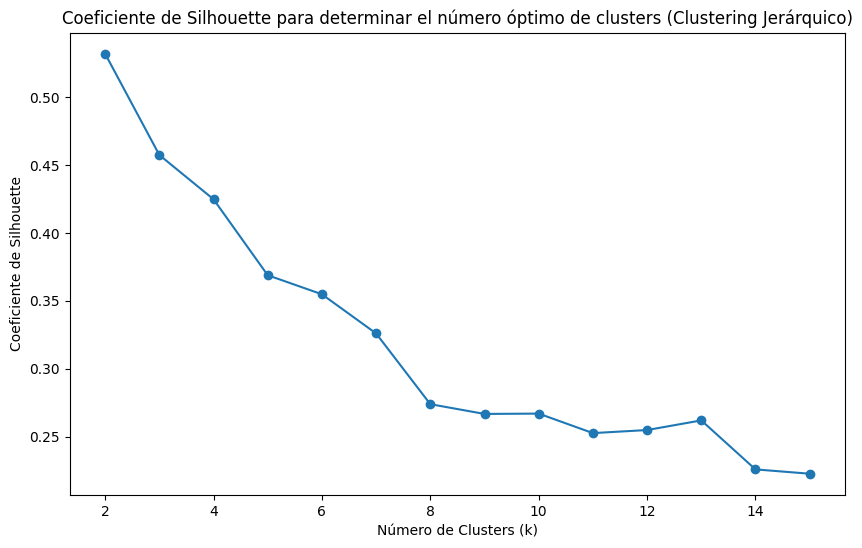

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(2, max_k + 1), silhouette_scores, marker='o')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Coeficiente de Silhouette')
plt.title('Coeficiente de Silhouette para determinar el número óptimo de clusters (Clustering Jerárquico)')
plt.show()

#### Observación:

## Conclusión: